# Симулятор уравнения Бюргерса (Хопфа)

Данный код решает скалярное нелинейное уравнение переноса, которое подчиняется уравнению в частных производных вида

$u_t + u u_x = 0$
  
несмотря на простоту модели, данная задача уже может указать на большинство проблем, которые могут встретиться при численном моделировании самых разных сплошных сред. 

Для решения уравнения Бюргерса код использует метод конечного объема с различными способами аппроксимации формулы для потока.


In [6]:
'''
#######################################################################################################################
#######################################################################################################################
#  
#  В данном блоке задаются необходимые нам библиотеки.
#  
#######################################################################################################################
#######################################################################################################################
'''

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output  # добавляем импорт clear_output и display
import time
import sys 

In [7]:
'''
#######################################################################################################################
#######################################################################################################################
# 
#  Для использования метода конечного объема зададим одномерную сетку на призме единичного сечения 
#     +-----+-----+-----+-----+-----+-----+-----+-----+
#    /  1  /     /     /     /     /     /     /     /|
#   /     /     /     /     /     /     /     /     / |
#  +-----+-----+-----+-----+-----+-----+-----+-----+  |
#  | 1   |     |     |     |     |     |     |     |  |
#  |     |     |     |     |     |     |     |     |  +
#  |     |     |     |     |     |     |     |     | /
#  |     |     |     |     |     |     |     |     |/
#  +--dx-+-----+-----+-----+-----+-----+-----+-----+
# 
#######################################################################################################################
#######################################################################################################################
'''

def grid_setup(xmin, xmax, Nx):
    #наша расчетная область - это призма с объемом x1*x2*x3 = (xmax - xmin)*1*1, которую мы "нарезаем" вдоль x
    #количество фиктивных ("ghost") ячеек
    Ngc = 2
    #разрешение сетки dx
    dx = (xmax - xmin)/Nx
    #задаем площадь грани и объем ячейки: fSurf = 1*1, сVol = 1*1*dx
    fSurf = 1.0
    cVol = dx
    #координата центра ячейки
    cx = np.linspace(xmin - (Ngc - 0.5) * dx, xmax + (Ngc - 0.5) * dx, Nx + 2 * Ngc, dtype=np.double)
    #координата грани ячейки
    fx = np.linspace(xmin - Ngc * dx, xmax + Ngc * dx, Nx + 2 * Ngc + 1, dtype=np.double)

    return Ngc, dx, fSurf, cVol, cx, fx

In [8]:
'''
#######################################################################################################################
#######################################################################################################################
#
#  ограничитель наклона для схем со вторым порядком точности 
#  обеспечивает монотонность решения вблизи разрывов без ухудшения его качества в областях гладкости
#  и не вносит в решение нефизичного осцилляторного поведения
#
#######################################################################################################################
#######################################################################################################################

'''
def limiter(x, y):

    #анализатор гладкости 
    r = (y + 1e-14) / (x + 1e-14)
    
    #van Leer limiter 
    xy = x * (np.abs(r) + r) / (1.0 + np.abs(r))

    #minmod limiter
    #xy = 0.5 * x * (1.0 + np.sign(r)) * np.minimum(1.0, np.abs(r))
    
    return xy

In [9]:
'''
#######################################################################################################################
#######################################################################################################################
#
# зададим решение в момент времени time = 0 в форме разрыва
# 
#######################################################################################################################
#######################################################################################################################
'''
def solution(xmin, xmax, cx, Nx, Ngc):

    #зададим исходные координаты разрыва
    x0 = xmin + (xmax - xmin)/2.0

    Ul = 0.0
    Ur = 1.0
    
    #задаем массив начальных данных в реальных ячейках
    for i in range(Ngc, Nx + Ngc):
        if cx[i] < x0:
            U0[i] = Ul
        else:
            U0[i] = Ur    
        
    #возвращаем решение в начальный момент
    return U0

In [10]:
'''
#######################################################################################################################
#######################################################################################################################
#
# точное решение задачи Римана для уравнения Бюргерса в точке x для времени t > 0
# 
#######################################################################################################################
#######################################################################################################################
'''
def Riemann(ul, ur, t, x):

    if ur < ul:
        if 0.5*(ul+ur) > 0.0:
            sol = ul
        elif 0.5*(ul+ur) < 0.0:
            sol = ur
        else:
            sol = 0.0
    elif ur > ul:
        if x/t <= ul:
            sol = ul
        elif x/t <= ur:
            sol = x/t
        else:
            sol = ur
    else:
        sol = 0.5*(ul+ur)

    #возвращаем решение
    return sol

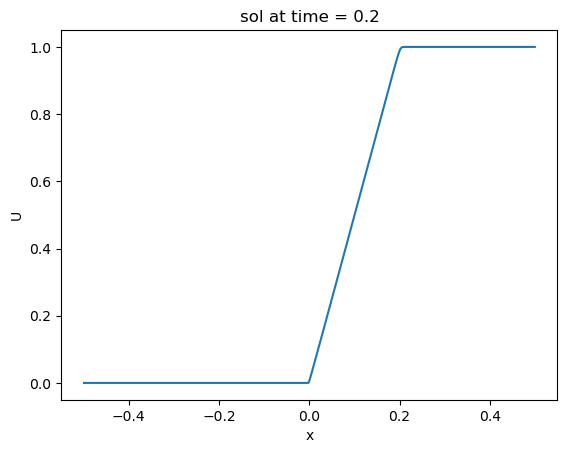

end of simulation


In [11]:
'''
#######################################################################################################################
#######################################################################################################################
# 
#   Здесь начинается основной код программы
# 
#######################################################################################################################
#######################################################################################################################
'''
#задаем нашу сетку - координаты границ и число ячеек
xmin = -0.5
xmax = 0.5
Nx = 1000

#задаем сеточные массивы
Ngc, dx, fSurf, cVol, cx, fx = grid_setup(xmin, xmax, Nx)

#инициализируем массивы решения U0 (текущий шаг по времени) и U1 (следующий шаг по времени), а также точное решение Ua
U0 = np.zeros(Nx + Ngc * 2, dtype=np.double)
U1 = np.zeros(Nx + Ngc * 2, dtype=np.double)

#инициализируем массив потоков в реальных гранях
flux = np.zeros(Nx+1, dtype=np.double)

#зададим параметр Куранта-Фридрихса-Леви
#CFL = 1.05
CFL = 0.5

#зададим начальные условия для времени time = 0, а также финальное время time_fin
U0 = solution(xmin, xmax, cx, Nx, Ngc)
time_fin = 0.2

#задаем начальное время равным нулю
time = 0.0
#задаем начальное число шагов
nts = 0

#если не работает ipython - можно поставить runtimeplot = 0
runtimeplot = 1
if runtimeplot == 1:
    # Создание фигуры для графика
    fig, ax = plt.subplots()
    line, = ax.plot(cx[Ngc:-Ngc], U0[Ngc:-Ngc])
    ax.set_title('solution at time = ' + str(np.round(time, 3)))
    ax.set_xlabel('x')
    ax.set_ylabel('U')
    plt.close()  # Закрываем фигуру, чтобы она не отображалась сразу


#цикл по времени
while time < time_fin - 1e-14:
    
    '''задаем шаг по времени'''
    dt = min(np.minimum(CFL * dx / np.abs(U0[Ngc:-Ngc]), time_fin - time))
    time += dt
    nts += 1

    '''задаем граничные условия с использованием фиктивных ячеек (в данном примере -- свободное протекание)'''
    for i in range(0,Ngc):
        #свободное протекание
        U0[i] = U0[2*Ngc-1-i]
        U0[Nx+Ngc+i] = U0[Nx+Ngc-1-i]
    
    '''схема с ограничителем наклона (второй порядок по времени и пространству везде кроме областей с экстремумами/разрывами/сильными градиентами)'''
    Ul = U0[Ngc-1:Nx+Ngc] + 1.0/2.0*(1.0 - U0[Ngc-1:Nx+Ngc]*dt/dx)*limiter(U0[Ngc-1:Nx+Ngc] - U0[Ngc-2:Nx+Ngc-1], U0[Ngc:Nx+Ngc+1] - U0[Ngc-1:Nx+Ngc])
    Ur = U0[Ngc:Nx+Ngc+1] - 1.0/2.0*(1.0 + U0[Ngc:Nx+Ngc+1]*dt/dx)*limiter(U0[Ngc:Nx+Ngc+1] - U0[Ngc-1:Nx+Ngc], U0[Ngc+1:Nx+Ngc+2] - U0[Ngc:Nx+Ngc+1])
    
    '''поток считается по схеме Русанова либо точным решателем'''
    #for i in range(Ngc,Ngc+1+Nx):
    #    print(i, fx[i])
    #    sol = Riemann(Ul[i-Ngc], Ur[i-Ngc], time + 0.5*dt, fx[i])
    #    flux[i-Ngc] = sol**2/2.0
    flux =  (Ul**2/2.0 + Ur**2/2.0) / 2.0 - np.maximum(np.abs(Ul), np.abs(Ur)) * (Ur - Ul) / 2.0
    
    '''обновляем наше численное решение'''
    U1[Ngc:-Ngc] = U0[Ngc:-Ngc] - dt * ( flux[1:] * fSurf - flux[:-1] * fSurf ) / cVol
    
    '''перезаписываем наше численное решение для использования на следующем шаге по времени'''
    #(в итоге мы храним только два решения, а не все слои по t)
    U0[Ngc:-Ngc] = U1[Ngc:-Ngc]

    '''вывод решения на экран'''
    if ((nts%20 == 0 or time > time_fin - 1e-13) & (runtimeplot == 1)):
        print('num of timesteps = ', nts)
        line.set_data(cx[Ngc:-Ngc], U1[Ngc:-Ngc])
        ax.set_title('sol at time = '+ str(np.round(time, 4)))
        
        # Автоматическое масштабирование осей
        ax.relim()
        ax.autoscale_view()
        
        clear_output(wait=True)
        # Обновление графика с задержкой
        plt.pause(0.1)
        display(fig)

plt.ioff()
plt.show()

print('end of simulation')

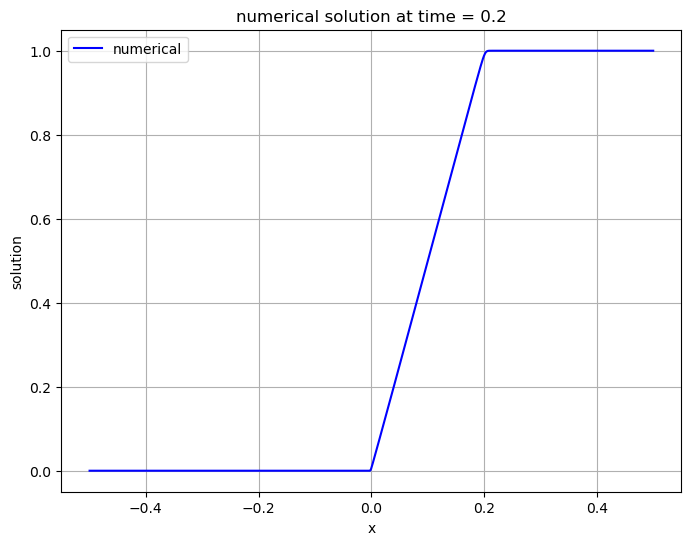

In [13]:
# Создаем новый график
plt.figure(figsize=(8, 6))

# Построение кривой (синяя линия)
plt.plot(cx[Ngc:-Ngc], U1[Ngc:-Ngc], label='numerical', color='blue')

# Добавление заголовка и меток осей
plt.title('numerical solution at time = ' + str(np.round(time, 4)))
plt.xlabel('x')
plt.ylabel('solution')
plt.grid(True)  # добавляем сетку

# Добавляем легенду
plt.legend()

# Отображаем график
plt.show()